In [12]:
import yaml
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import load_and_preprocess_data
from src.metrics import accuracy_score, confusion_matrix, precision_recall_f1_macro
from src.models.one_rule import OneRule
from src.models.decision_tree import DecisionTree
from src.models.knn import KNN
from src.models.naive_bayes import GaussianNaiveBayes

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier as OneRuleSklearn
from sklearn.metrics import ConfusionMatrixDisplay

def load_config(config_path: str) -> dict:
    with open(config_path, "r") as f:
        return yaml.safe_load(f)

config = load_config("config.yaml")

In [6]:
print("Raw data:")
raw_df = pd.read_csv(config['data']['path'])
display(raw_df.head())

Raw data:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [7]:
X_train, X_test, y_train, y_test, le, feature_names = load_and_preprocess_data(
    csv_path=config['data']['path'],
    drop_cols=config['data']['drop_columns'],
    target_col=config['data']['target_column'],
    test_size=config['data']['test_size'],
    random_state=config['data']['random_state']
)

print(f"Train set shape: {X_train.shape}")
print("Data after ColumnTransformer:")
processed_df = pd.DataFrame(X_train, columns=feature_names)
processed_df['Target_Encoded'] = y_train
display(processed_df.head())

Train set shape: (1913, 29)
Data after ColumnTransformer:


,num__Age,num__StudyTimeWeekly,num__Absences,cat__Gender_0,cat__Gender_1,cat__Ethnicity_0,cat__Ethnicity_1,cat__Ethnicity_2,cat__Ethnicity_3,cat__ParentalEducation_0,...,cat__ParentalSupport_4,cat__Extracurricular_0,cat__Extracurricular_1,cat__Sports_0,cat__Sports_1,cat__Music_0,cat__Music_1,cat__Volunteering_0,cat__Volunteering_1,Target_Encoded
0,-1.308429,-1.384170,-0.902052,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3
1,0.475623,0.152788,0.398611,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,4
2,-0.416403,-0.623951,1.462791,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,4
3,-1.308429,-0.636208,1.108065,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,4
4,-1.308429,-1.667884,0.989822,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,4


In [14]:
def train_and_evaluate(models_dict, X_train, y_train, X_test, y_test):
    results = {}
    for name, model in models_dict.items():
        start_fit = time.perf_counter()
        model.fit(X_train, y_train)
        fit_time = time.perf_counter() - start_fit
        
        start_pred = time.perf_counter()
        preds = model.predict(X_test)
        predict_time = time.perf_counter() - start_pred
        
        acc = accuracy_score(y_test, preds)
        prec, rec, f1 = precision_recall_f1_macro(y_test, preds)
        cm = confusion_matrix(y_test, preds)
        
        results[name] = {
            'Accuracy': acc, 'Precision': prec, 
            'Recall': rec, 'F1': f1, 
            'Fit_Time': fit_time, 'Predict_Time': predict_time,
            'Confusion_Matrix': cm
        }
    return results

def print_comparison_table(custom_results, sklearn_results):
    print("=" * 115)
    print(f"{'Model':<28} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-score':<10} | {'Fit Time (s)':<12} | {'Pred Time (s)':<12}")
    print("-" * 115)
    
    all_results = {}
    for k, v in custom_results.items():
        all_results[f"Custom {k}"] = v
    for k, v in sklearn_results.items():
        all_results[f"Sklearn {k}"] = v
        
    sorted_results = sorted(all_results.items(), key=lambda x: (x[0].split()[1], x[0].split()[0]))
    
    for name, metrics in sorted_results:
        print(f"{name:<28} | {metrics['Accuracy']:<10.4f} | {metrics['Precision']:<10.4f} | {metrics['Recall']:<10.4f} | {metrics['F1']:<10.4f} | {metrics['Fit_Time']:<12.6f} | {metrics['Predict_Time']:<12.6f}")

In [15]:
# Custom models
custom_models = {
    'DecisionTree': DecisionTree(max_depth=config['models']['decision_tree']['max_depth'], 
                                 min_samples_split=config['models']['decision_tree']['min_samples_split']),
    'GaussianNB': GaussianNaiveBayes(var_smoothing=config['models']['gaussian_naive_bayes']['var_smoothing']),
    'KNN': KNN(k=config['models']['knn']['k']),
    'OneRule': OneRule()
}

# Sklearn models
sklearn_models = {
    'DecisionTree': DecisionTreeClassifier(max_depth=config['models']['decision_tree']['max_depth'], 
                                           min_samples_split=config['models']['decision_tree']['min_samples_split'],
                                           random_state=42),
    'GaussianNB': GaussianNB(var_smoothing=config['models']['gaussian_naive_bayes']['var_smoothing']),
    'KNN': KNeighborsClassifier(n_neighbors=config['models']['knn']['k']),
    'OneRule': OneRuleSklearn(max_depth=1, random_state=42) # Decision Stump
}

print("Training custom models...")
custom_res = train_and_evaluate(custom_models, X_train, y_train, X_test, y_test)

print("Training sklearn models...")
sklearn_res = train_and_evaluate(sklearn_models, X_train, y_train, X_test, y_test)

print_comparison_table(custom_res, sklearn_res)

Training custom models...
Training sklearn models...
Model                        | Accuracy   | Precision  | Recall     | F1-score   | Fit Time (s) | Pred Time (s)
-------------------------------------------------------------------------------------------------------------------
Custom DecisionTree          | 0.7077     | 0.6315     | 0.5473     | 0.5411     | 1.475989     | 0.000733    
Sklearn DecisionTree         | 0.6910     | 0.5869     | 0.5222     | 0.5248     | 0.005315     | 0.000334    
Custom GaussianNB            | 0.6159     | 0.4405     | 0.4600     | 0.4453     | 0.000583     | 0.043575    
Sklearn GaussianNB           | 0.6159     | 0.4405     | 0.4600     | 0.4453     | 0.002032     | 0.000556    
Custom KNN                   | 0.6200     | 0.4393     | 0.4298     | 0.4316     | 0.000056     | 0.061795    
Sklearn KNN                  | 0.6200     | 0.4393     | 0.4298     | 0.4316     | 0.000574     | 0.002750    
Custom OneRule               | 0.5073     | 0.1015   

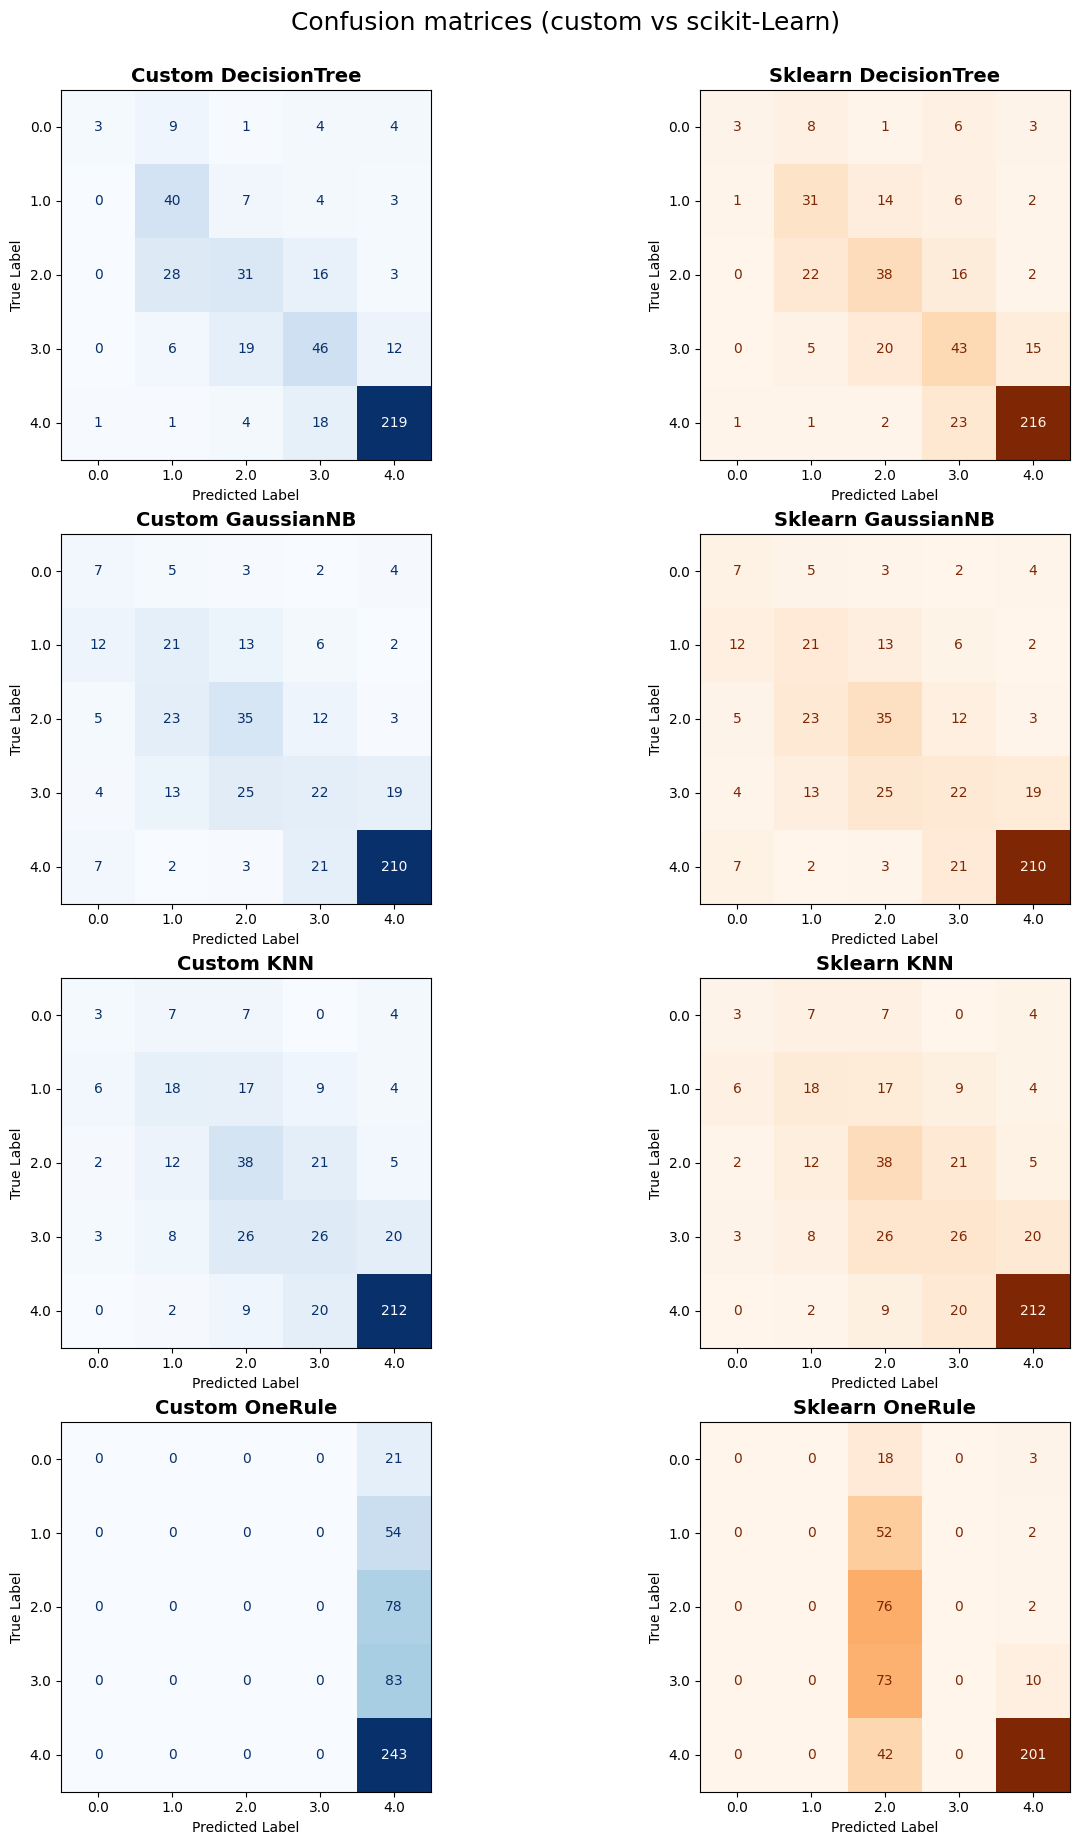

In [16]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 20))
fig.suptitle('Confusion matrices (custom vs scikit-Learn)', fontsize=18, y=0.92)

model_names = list(custom_models.keys())

for i, name in enumerate(model_names):
    # Custom model
    cm_custom = custom_res[name]['Confusion_Matrix']
    disp_custom = ConfusionMatrixDisplay(confusion_matrix=cm_custom, display_labels=le.classes_)
    disp_custom.plot(ax=axes[i, 0], cmap='Blues', colorbar=False, values_format='d')
    axes[i, 0].set_title(f'Custom {name}', fontsize=14, fontweight='bold')
    axes[i, 0].set_xlabel('Predicted Label')
    axes[i, 0].set_ylabel('True Label')

    # Sklearn model
    cm_sklearn = sklearn_res[name]['Confusion_Matrix']
    disp_sklearn = ConfusionMatrixDisplay(confusion_matrix=cm_sklearn, display_labels=le.classes_)
    disp_sklearn.plot(ax=axes[i, 1], cmap='Oranges', colorbar=False, values_format='d')
    axes[i, 1].set_title(f'Sklearn {name}', fontsize=14, fontweight='bold')
    axes[i, 1].set_xlabel('Predicted Label')
    axes[i, 1].set_ylabel('True Label')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

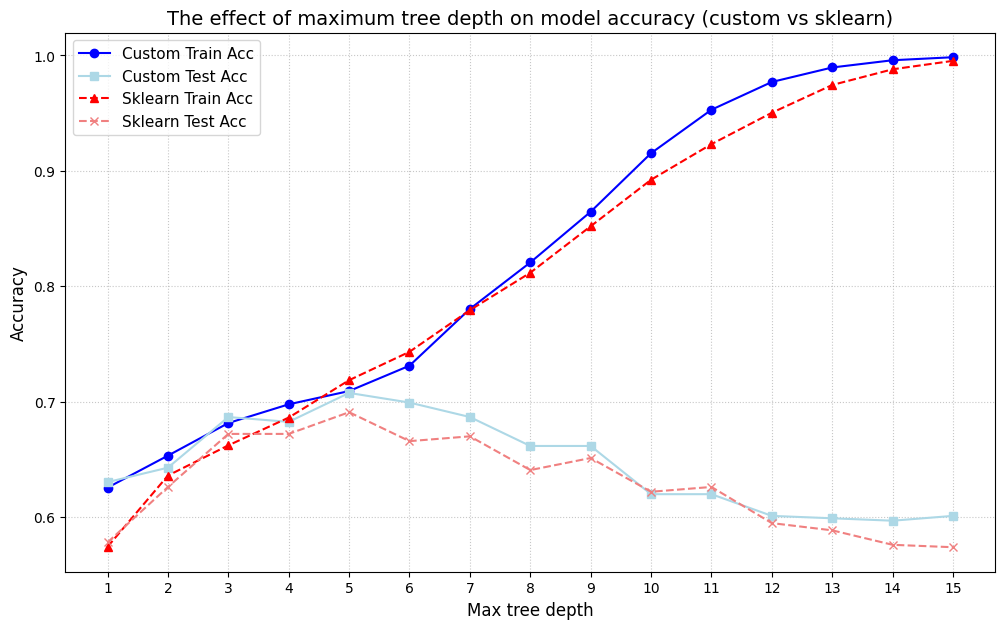

In [17]:
max_depths = list(range(1, 16))
train_scores_custom, test_scores_custom = [], []
train_scores_sk, test_scores_sk = [], []

for depth in max_depths:
    # Custom
    tree_custom = DecisionTree(max_depth=depth, min_samples_split=2)
    tree_custom.fit(X_train, y_train)
    train_scores_custom.append(accuracy_score(y_train, tree_custom.predict(X_train)))
    test_scores_custom.append(accuracy_score(y_test, tree_custom.predict(X_test)))
    
    # Sklearn
    tree_sk = DecisionTreeClassifier(max_depth=depth, min_samples_split=2, random_state=42)
    tree_sk.fit(X_train, y_train)
    train_scores_sk.append(accuracy_score(y_train, tree_sk.predict(X_train)))
    test_scores_sk.append(accuracy_score(y_test, tree_sk.predict(X_test)))

plt.figure(figsize=(12, 7))

plt.plot(max_depths, train_scores_custom, label='Custom Train Acc', marker='o', color='blue', linestyle='-')
plt.plot(max_depths, test_scores_custom, label='Custom Test Acc', marker='s', color='lightblue', linestyle='-')

plt.plot(max_depths, train_scores_sk, label='Sklearn Train Acc', marker='^', color='red', linestyle='--')
plt.plot(max_depths, test_scores_sk, label='Sklearn Test Acc', marker='x', color='lightcoral', linestyle='--')

plt.title('The effect of maximum tree depth on model accuracy (custom vs sklearn)', fontsize=14)
plt.xlabel('Max tree depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(max_depths)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.show()